<a href="https://colab.research.google.com/github/LujainAldujain/Data_Mining_Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Summarization and Preprocessing

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Numerical Attributes

The numerical attributes selected for this analysis are tenure, MonthlyCharges, and TotalCharges.

SeniorCitizen was excluded from the numerical outlier analysis because it is a binary attribute represented by 0 and 1 rather than a continuous numerical variable.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Numerical Attributes:")
print(numeric_columns)

Numerical Attributes:
['tenure', 'MonthlyCharges', 'TotalCharges']


### Five-Number Summary

The five-number summary presents the minimum, first quartile (Q1), median, third quartile (Q3), and maximum values for each numerical attribute.

It provides an overview of the distribution and spread of tenure, MonthlyCharges, and TotalCharges and helps identify possible extreme values in the dataset.

In [10]:
five_number_summary = df[numeric_columns].describe().loc[
    ['min', '25%', '50%', '75%', 'max']
]

five_number_summary

,tenure,MonthlyCharges,TotalCharges
min,0.0,18.25,18.8000
25%,9.0,35.50,401.4500
50%,29.0,70.35,1397.4750
75%,55.0,89.85,3794.7375
max,72.0,118.75,8684.8000


### Outlier Analysis

The Interquartile Range (IQR) method was used to identify potential outliers in the numerical attributes.

The IQR is calculated as:

IQR = Q3 - Q1

Values below Q1 - 1.5(IQR) or above Q3 + 1.5(IQR) are considered potential outliers.

Identifying outliers is important because extreme values may influence statistical analysis and machine learning models and may therefore require further consideration during preprocessing.

In [11]:
for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Attribute:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("--------------------------------")

Attribute: tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0
--------------------------------
Attribute: MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of Outliers: 0
--------------------------------
Attribute: TotalCharges
Q1: 401.45
Q3: 3794.7375
IQR: 3393.2875000000004
Lower Bound: -4688.481250000001
Upper Bound: 8884.66875
Number of Outliers: 0
--------------------------------


##boxplot of tenure
The boxplot of tenure shows the distribution of customer tenure. It provides a visual representation of the median, quartiles, spread, and any potential outliers.

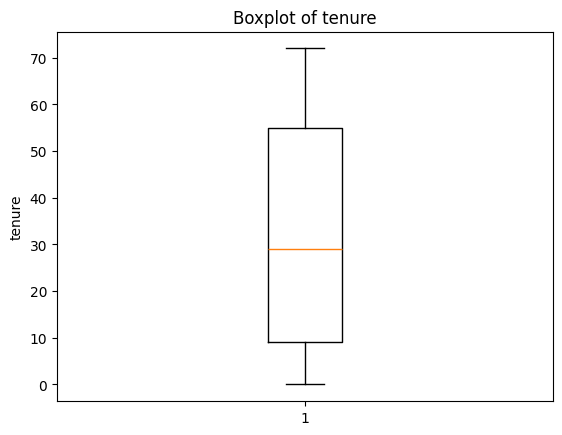

In [12]:
plt.figure()
plt.boxplot(df['tenure'].dropna())
plt.title("Boxplot of tenure")
plt.ylabel("tenure")
plt.show()

##boxplot of MonthlyCharges
The boxplot of MonthlyCharges shows the distribution of customers' monthly charges. It helps identify the spread of values and whether any observations fall outside the expected range.

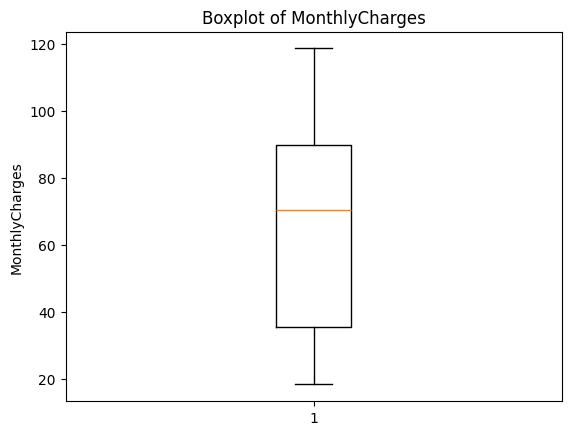

In [13]:
plt.figure()
plt.boxplot(df['MonthlyCharges'].dropna())
plt.title("Boxplot of MonthlyCharges")
plt.ylabel("MonthlyCharges")
plt.show()

##boxplot of TotalCharges
The boxplot of TotalCharges shows the distribution of the total amount charged to customers. It helps visualize the median, variability, and potential extreme values in this attribute.

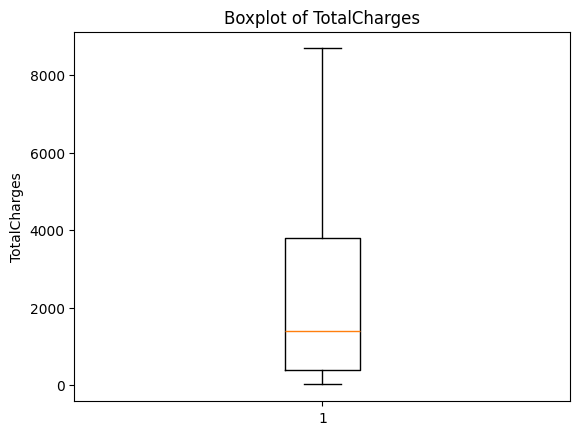

In [14]:
plt.figure()
plt.boxplot(df['TotalCharges'].dropna())
plt.title("Boxplot of TotalCharges")
plt.ylabel("TotalCharges")
plt.show()

### Numerical Data Analysis

The five-number summary, IQR method, and boxplots were used to analyze the numerical attributes.

These techniques provide information about the center, spread, and possible extreme values in the dataset. The results can help determine whether some numerical attributes require preprocessing before applying data mining techniques.

No outliers were removed in this section because this part focuses only on analyzing the data. Any necessary treatment will be performed during the preprocessing stage.